# Netflix Data Analysis

## Project Overview

This project analyzes the Netflix Movies and TV Shows dataset to uncover insights about content distribution, release trends, genres, countries, ratings, and other key business metrics.

The project demonstrates the complete data analysis workflow, including:

- Data Loading
- Data Inspection
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Data Visualization
- Business Insights
- Final Conclusions

## Import Required Libraries

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load the Dataset

In [22]:
import os
print(os.getcwd())

c:\Users\HP\OneDrive\Desktop\Netflix_Data_Analysis\notebooks


In [18]:
df = pd.read_csv("../data/netflix_titles.csv")

## Initial Data Inspection

In [24]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


### Dataset Shape

In [29]:
df.shape

(8807, 12)

### Column Names

In [30]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

### Dataset Information

In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


## Dataset Summary Statistics

In [32]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


## Missing Values Analysis

In [33]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

## Missing Values Percentage

In [34]:
(df.isnull().sum() / len(df)) * 100

show_id          0.000000
type             0.000000
title            0.000000
director        29.908028
cast             9.367549
country          9.435676
date_added       0.113546
release_year     0.000000
rating           0.045418
duration         0.034064
listed_in        0.000000
description      0.000000
dtype: float64

## Duplicate Records

In [35]:
df.duplicated().sum()

np.int64(0)

# Data Quality Assessment

## Data Types

In [36]:
df.dtypes

show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object

## Unique Values in Each Column

In [38]:
df.nunique()

show_id         8807
type               2
title           8807
director        4528
cast            7692
country          748
date_added      1767
release_year      74
rating            17
duration         220
listed_in        514
description     8775
dtype: int64

Movie
TV Show

## Sample Values of Each Column

In [39]:
for column in df.columns:
    print(f"\n{column}")
    print(df[column].unique()[:10])


show_id
<StringArray>
['s1', 's2', 's3', 's4', 's5', 's6', 's7', 's8', 's9', 's10']
Length: 10, dtype: str

type
<StringArray>
['Movie', 'TV Show']
Length: 2, dtype: str

title
<StringArray>
[            'Dick Johnson Is Dead',                    'Blood & Water',
                        'Ganglands',            'Jailbirds New Orleans',
                     'Kota Factory',                    'Midnight Mass',
 'My Little Pony: A New Generation',                          'Sankofa',
    'The Great British Baking Show',                     'The Starling']
Length: 10, dtype: str

director
<StringArray>
[              'Kirsten Johnson',                             nan,
               'Julien Leclercq',                 'Mike Flanagan',
 'Robert Cullen, José Luis Ucha',                  'Haile Gerima',
               'Andy Devonshire',                'Theodore Melfi',
             'Kongkiat Komesiri',           'Christian Schwochow']
Length: 10, dtype: str

cast
<StringArray>
[                 

## Missing Value Visualization

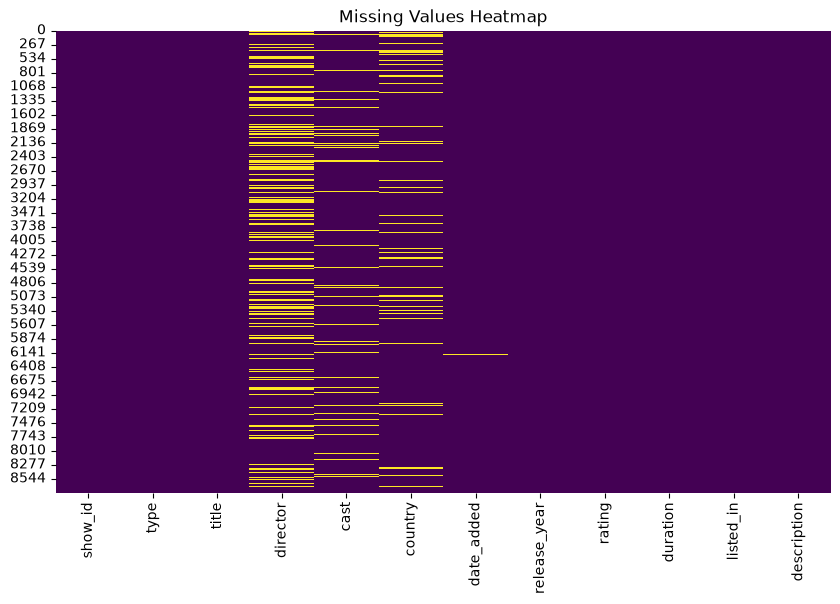

In [113]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.savefig("../images/missing_values_heatmap.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

# Data Cleaning

## Create a Copy of the Original Dataset

In [41]:
df_clean = df.copy()

## Verify Missing Values

In [42]:
df_clean.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

## Remove Duplicate Records

In [43]:
df_clean = df_clean.drop_duplicates()

In [44]:
df_clean.duplicated().sum()

np.int64(0)

## Handle Missing Values

### Missing Values in Director

In [45]:
df_clean["director"].isnull().sum()

np.int64(2634)

### Missing Values in Cast

In [46]:
df_clean["cast"].isnull().sum()

np.int64(825)

### Missing Values in Country

In [47]:
df_clean["country"].isnull().sum()

np.int64(831)

### Missing Values in Date Added

In [48]:
df_clean["date_added"].isnull().sum()

np.int64(10)

### Missing Values in Rating

In [49]:
df_clean["rating"].isnull().sum()

np.int64(4)

In [50]:
df_clean.fillna(...)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Ellipsis,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Ellipsis,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Ellipsis,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Ellipsis,Ellipsis,Ellipsis,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Ellipsis,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,Ellipsis,Ellipsis,Ellipsis,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


## Handle Missing Values in `director`

In [51]:
df_clean["director"] = df_clean["director"].fillna("Unknown")

## Handle Missing Values in `cast`

In [52]:
df_clean["cast"] = df_clean["cast"].fillna("Unknown")

## Handle Missing Values in `country`

In [53]:
df_clean["country"] = df_clean["country"].fillna("Unknown")

## Handle Missing Values in `rating`

In [54]:
df_clean["rating"] = df_clean["rating"].fillna("Not Rated")

## Handle Missing Values in `date_added`

In [55]:
df_clean = df_clean.dropna(subset=["date_added"])

## Verify Missing Values After Cleaning

In [56]:
df_clean.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        3
listed_in       0
description     0
dtype: int64

## Dataset Shape After Cleaning

In [57]:
df_clean.shape

(8797, 12)

## Save Clean Dataset (Optional)

In [58]:
df_clean.to_csv("../data/netflix_clean.csv", index=False)

# Feature Engineering

## Convert `date_added` to Datetime

In [61]:
df_clean["date_added"] = pd.to_datetime(
    df_clean["date_added"],
    errors="coerce"
)

## Verify Data Type

In [62]:
df_clean["date_added"].dtype

dtype('<M8[us]')

## Extract Year Added

In [63]:
df_clean["year_added"] = df_clean["date_added"].dt.year

## Extract Month Added

In [64]:
df_clean["month_added"] = df_clean["date_added"].dt.month_name()

## Extract Day Added

In [65]:
df_clean["day_added"] = df_clean["date_added"].dt.day

## Extract Weekday Added

In [66]:
df_clean["weekday_added"] = df_clean["date_added"].dt.day_name()

## Verify Newly Created Columns

In [67]:
df_clean[
    [
        "date_added",
        "year_added",
        "month_added",
        "day_added",
        "weekday_added"
    ]
].head()

,date_added,year_added,month_added,day_added,weekday_added
0,2021-09-25,2021.0,September,25.0,Saturday
1,2021-09-24,2021.0,September,24.0,Friday
2,2021-09-24,2021.0,September,24.0,Friday
3,2021-09-24,2021.0,September,24.0,Friday
4,2021-09-24,2021.0,September,24.0,Friday


## Split Duration into Value and Unit

In [68]:
df_clean[["duration_value", "duration_unit"]] = (
    df_clean["duration"].str.split(" ", n=1, expand=True)
)

## Convert Duration Value to Integer

In [70]:
df_clean["duration_value"] = pd.to_numeric(
    df_clean["duration_value"],
    errors="coerce"
)

## Verify Duration Columns

In [73]:
df_clean[
    [
        "duration",
        "duration_value",
        "duration_unit"
    ]
].head()

,duration,duration_value,duration_unit
0,90 min,90,min
1,2 Seasons,2,Seasons
2,1 Season,1,Season
3,1 Season,1,Season
4,2 Seasons,2,Seasons


## Dataset Preview After Feature Engineering

In [75]:
df_clean.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,day_added,weekday_added,duration_value,duration_unit
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,September,25.0,Saturday,90,min
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,September,24.0,Friday,2,Seasons
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,September,24.0,Friday,1,Season
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,September,24.0,Friday,1,Season
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,September,24.0,Friday,2,Seasons


# Exploratory Data Analysis (EDA)

## Distribution of Content Type

In [76]:
df_clean["type"].value_counts()

type
Movie      6128
TV Show    2666
Name: count, dtype: int64

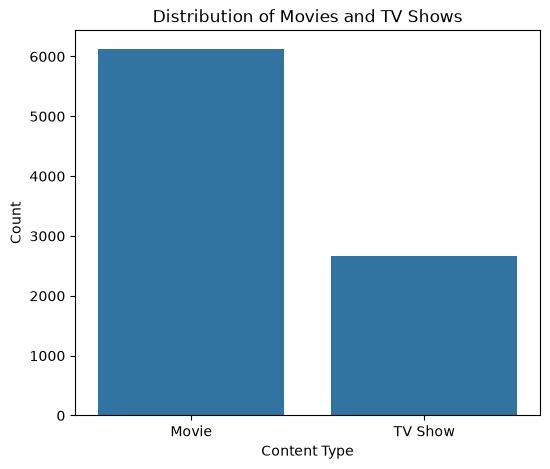

In [112]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df_clean,
    x="type"
)

plt.title("Distribution of Movies and TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Count")

plt.savefig("../images/distribution_movies_tvshows.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

## Content Added Each Year

In [78]:
year_counts = (
    df_clean["year_added"]
    .value_counts()
    .sort_index()
)

year_counts

year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      10
2014.0      23
2015.0      73
2016.0     416
2017.0    1163
2018.0    1625
2019.0    1999
2020.0    1878
2021.0    1498
Name: count, dtype: int64

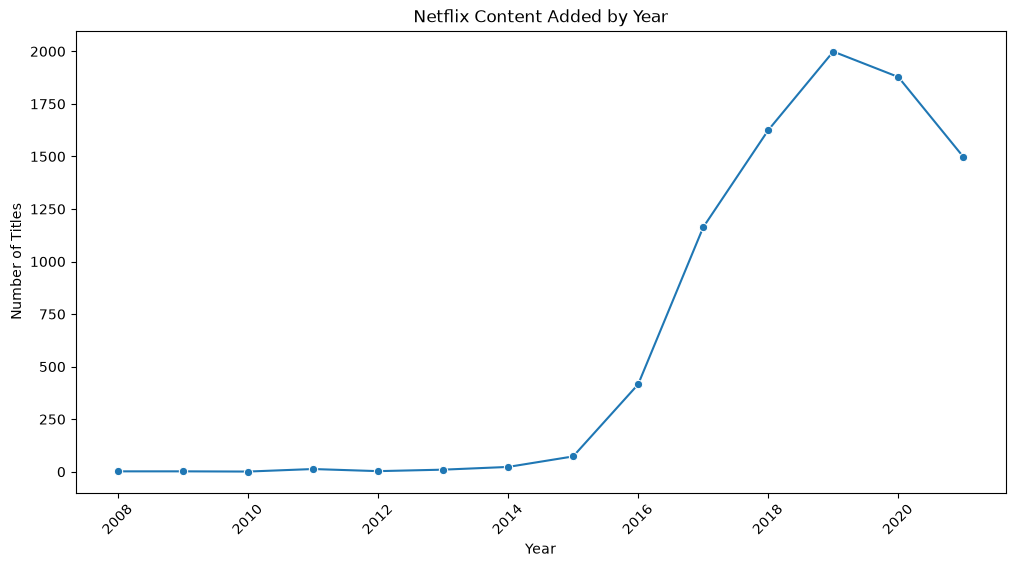

In [110]:
plt.figure(figsize=(12,6))

sns.lineplot(
    x=year_counts.index,
    y=year_counts.values,
    marker="o"
)

plt.title("Netflix Content Added by Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.xticks(rotation=45)

plt.savefig("../images/content_added_by_year.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

## Monthly Content Additions

In [80]:
month_order = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]

month_counts = (
    df_clean["month_added"]
    .value_counts()
    .reindex(month_order)
)

month_counts

month_added
January      727
February     557
March        734
April        758
May          626
June         724
July         819
August       748
September    764
October      755
November     697
December     797
Name: count, dtype: int64

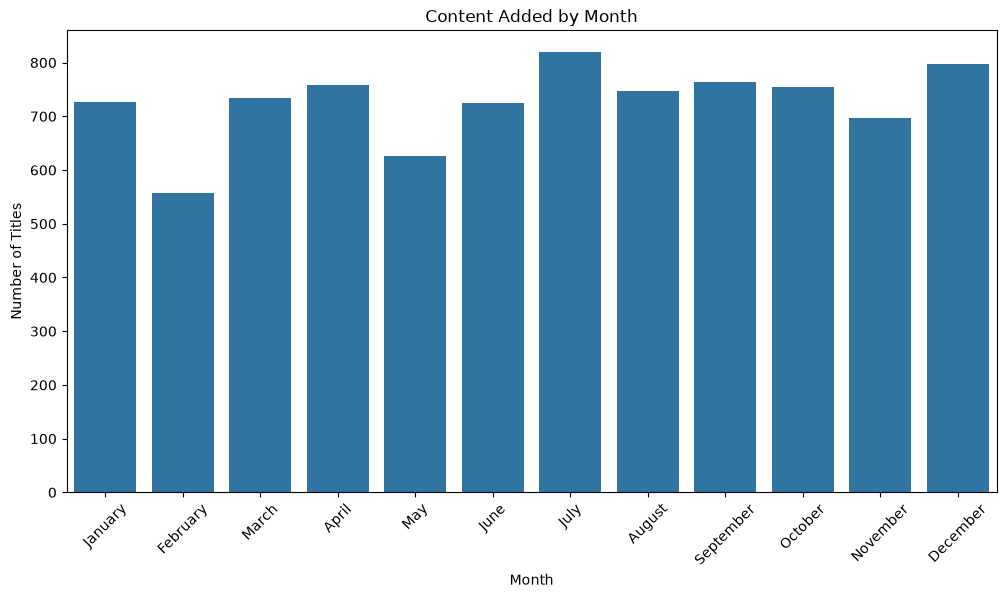

In [109]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=month_counts.index,
    y=month_counts.values
)

plt.xticks(rotation=45)

plt.title("Content Added by Month")
plt.xlabel("Month")
plt.ylabel("Number of Titles")

plt.savefig("../images/content_added_by_month.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

## Top 10 Content Producing Countries

In [82]:
country_counts = (
    df_clean["country"]
    .str.split(", ")
    .explode()
    .value_counts()
    .head(10)
)

country_counts

country
United States     3680
India             1046
Unknown            830
United Kingdom     803
Canada             445
France             393
Japan              317
Spain              232
South Korea        231
Germany            226
Name: count, dtype: int64

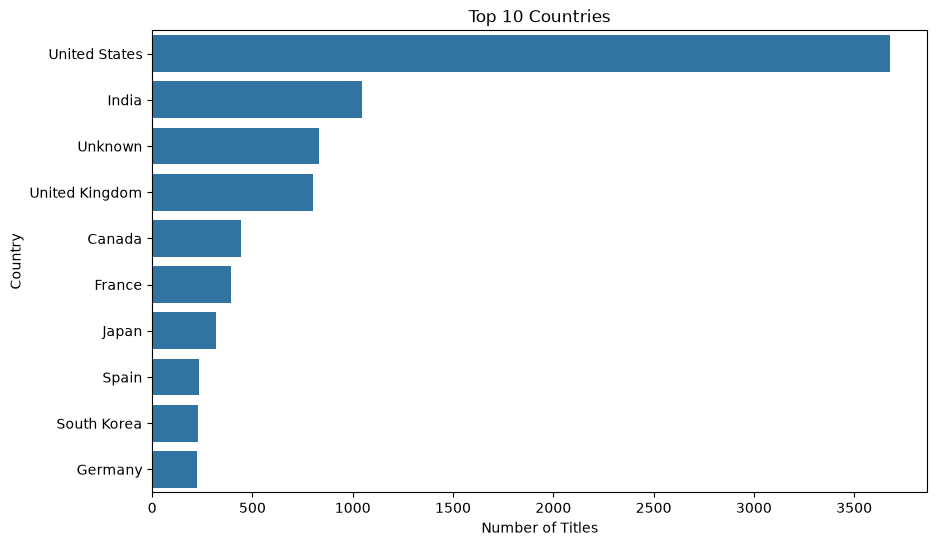

In [108]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=country_counts.values,
    y=country_counts.index
)

plt.title("Top 10 Countries")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.savefig("../images/top10_countries.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

## Top 10 Genres

In [84]:
genre_counts = (
    df_clean["listed_in"]
    .str.split(", ")
    .explode()
    .value_counts()
    .head(10)
)

genre_counts

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1350
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

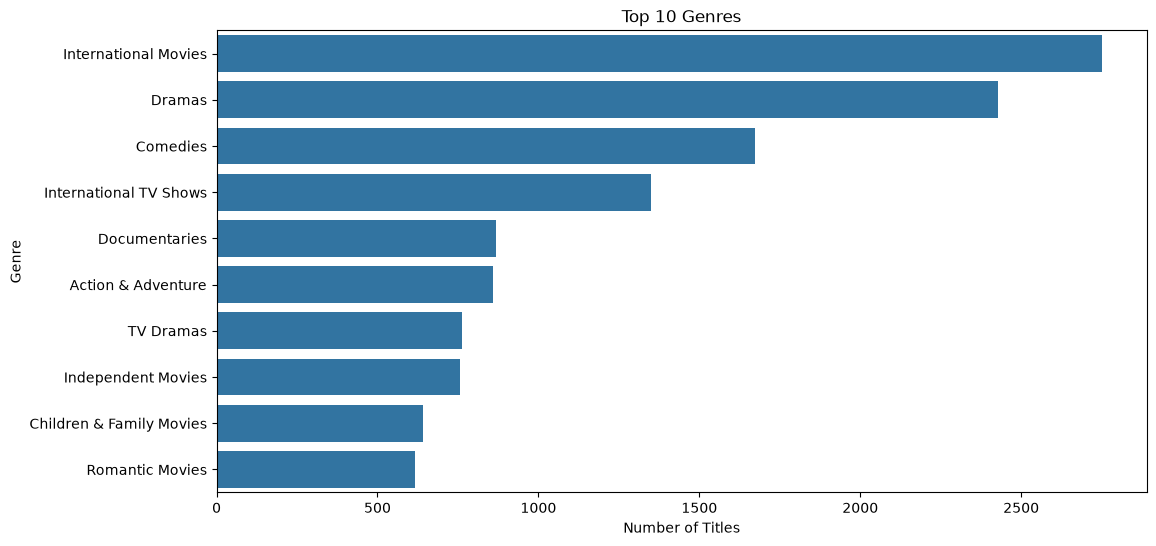

In [107]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=genre_counts.values,
    y=genre_counts.index
)

plt.title("Top 10 Genres")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

plt.savefig("../images/top10_genres.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

## Top 10 Directors

In [86]:
director_counts = (
    df_clean["director"]
    .value_counts()
    .head(10)
)

director_counts

director
Unknown                   2624
Rajiv Chilaka               19
Raúl Campos, Jan Suter      18
Suhas Kadav                 16
Marcus Raboy                16
Jay Karas                   14
Cathy Garcia-Molina         13
Youssef Chahine             12
Martin Scorsese             12
Jay Chapman                 12
Name: count, dtype: int64

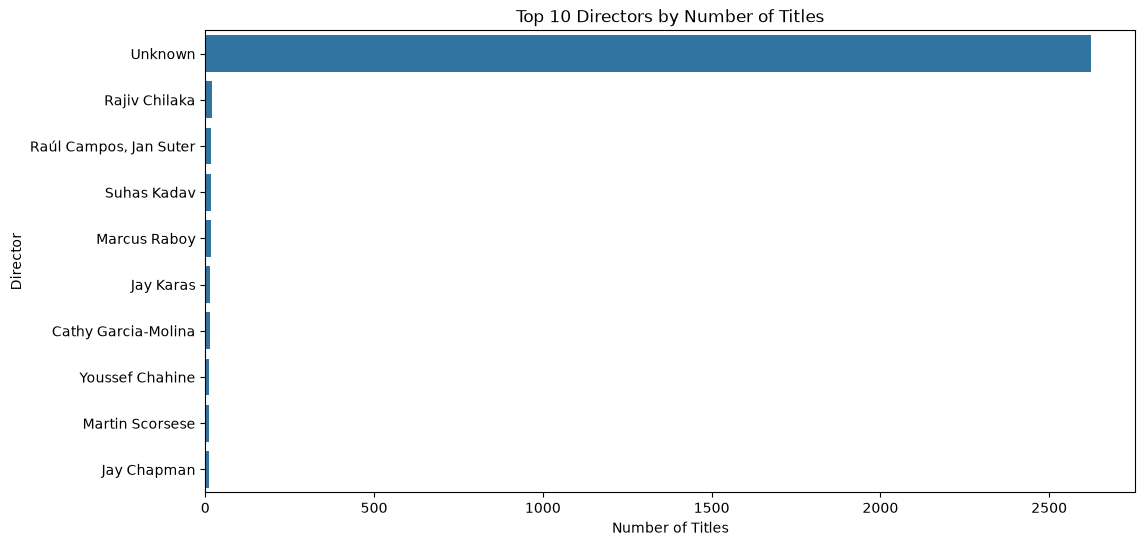

In [106]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=director_counts.values,
    y=director_counts.index
)

plt.title("Top 10 Directors by Number of Titles")
plt.xlabel("Number of Titles")
plt.ylabel("Director")

plt.savefig("../images/top10_directors.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

## Top 10 Actors

In [88]:
actor_counts = (
    df_clean["cast"]
    .str.split(", ")
    .explode()
    .value_counts()
    .drop("Unknown", errors="ignore")
    .head(10)
)

actor_counts

cast
Anupam Kher         43
Shah Rukh Khan      35
Julie Tejwani       33
Naseeruddin Shah    32
Takahiro Sakurai    32
Rupa Bhimani        31
Akshay Kumar        30
Om Puri             30
Yuki Kaji           29
Amitabh Bachchan    28
Name: count, dtype: int64

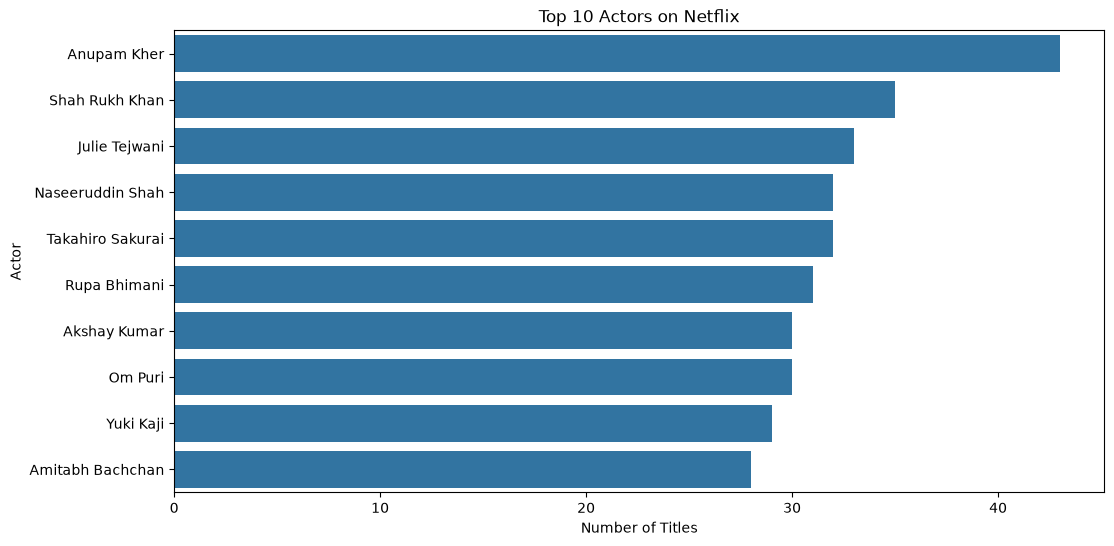

In [114]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=actor_counts.values,
    y=actor_counts.index
)

plt.title("Top 10 Actors on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Actor")

plt.savefig(
    "../images/top10_actors.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Content Ratings

In [90]:
rating_counts = df_clean["rating"].value_counts()

rating_counts

rating
TV-MA        3205
TV-14        2157
TV-PG         861
R             799
PG-13         490
TV-Y7         333
TV-Y          306
PG            287
TV-G          220
NR             79
G              41
TV-Y7-FV        6
Not Rated       4
NC-17           3
UR              3
Name: count, dtype: int64

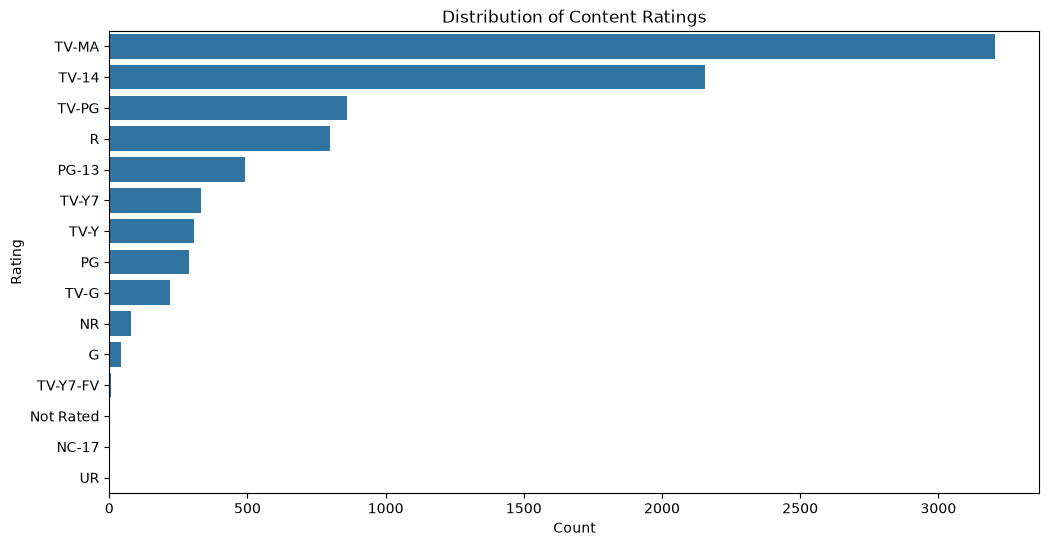

In [105]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df_clean,
    y="rating",
    order=df_clean["rating"].value_counts().index
)

plt.title("Distribution of Content Ratings")
plt.xlabel("Count")
plt.ylabel("Rating")

plt.savefig("../images/content_ratings.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

## Movie Duration Distribution

In [92]:
movies = df_clean[df_clean["type"] == "Movie"]

movies.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,day_added,weekday_added,duration_value,duration_unit
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,September,25.0,Saturday,90,min
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",Unknown,2021-09-24,2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,2021.0,September,24.0,Friday,91,min
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",2021.0,September,24.0,Friday,125,min
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...,2021.0,September,24.0,Friday,104,min
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic",2021-09-23,2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...,2021.0,September,23.0,Thursday,127,min


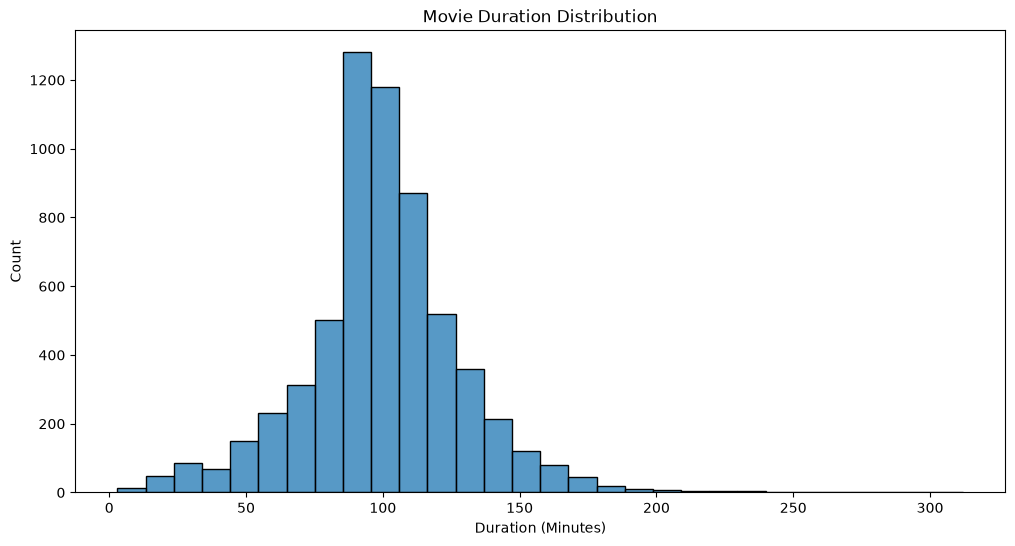

In [104]:
plt.figure(figsize=(12,6))

sns.histplot(
    data=movies,
    x="duration_value",
    bins=30
)

plt.title("Movie Duration Distribution")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Count")

plt.savefig("../images/movie_duration_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

## TV Show Seasons Distribution

In [94]:
tv_shows = df_clean[df_clean["type"] == "TV Show"]

tv_shows.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,day_added,weekday_added,duration_value,duration_unit
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,September,24.0,Friday,2,Seasons
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,September,24.0,Friday,1,Season
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,September,24.0,Friday,1,Season
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,September,24.0,Friday,2,Seasons
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",Unknown,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...,2021.0,September,24.0,Friday,1,Season


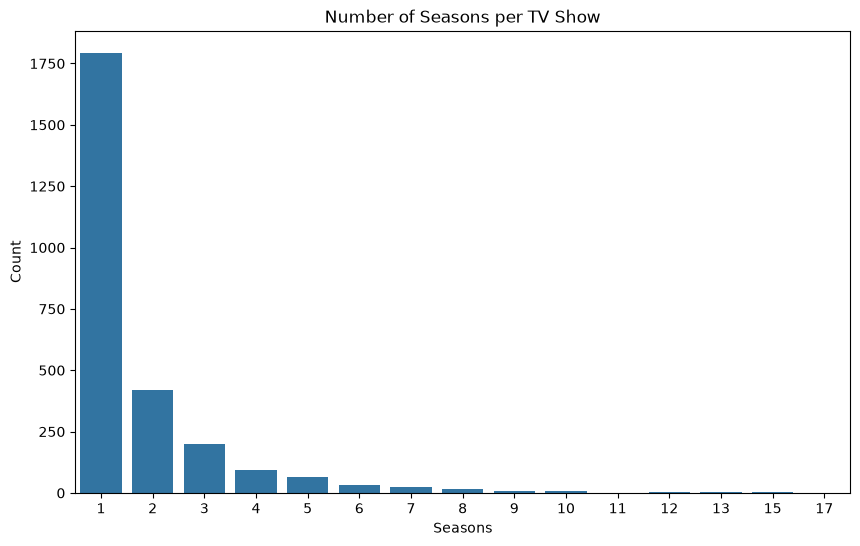

In [103]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=tv_shows,
    x="duration_value"
)

plt.title("Number of Seasons per TV Show")
plt.xlabel("Seasons")
plt.ylabel("Count")

plt.savefig("../images/tvshow_seasons_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

## Movie vs TV Show Comparison

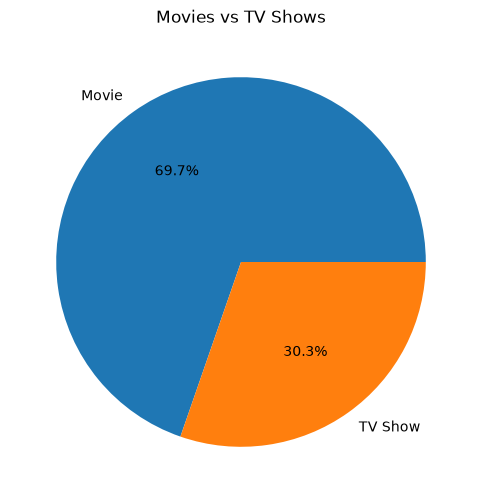

In [102]:
df_clean["type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.ylabel("")
plt.title("Movies vs TV Shows")
plt.savefig("../images/movies_vs_tvshows.png",
            dpi=300,
            bbox_inches="tight")

plt.savefig("../images/movies_tvshows_piechart.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

## Top Release Years

In [97]:
release_counts = (
    df_clean["release_year"]
    .value_counts()
    .sort_index()
)

release_counts.tail()

release_year
2017    1031
2018    1146
2019    1030
2020     953
2021     592
Name: count, dtype: int64

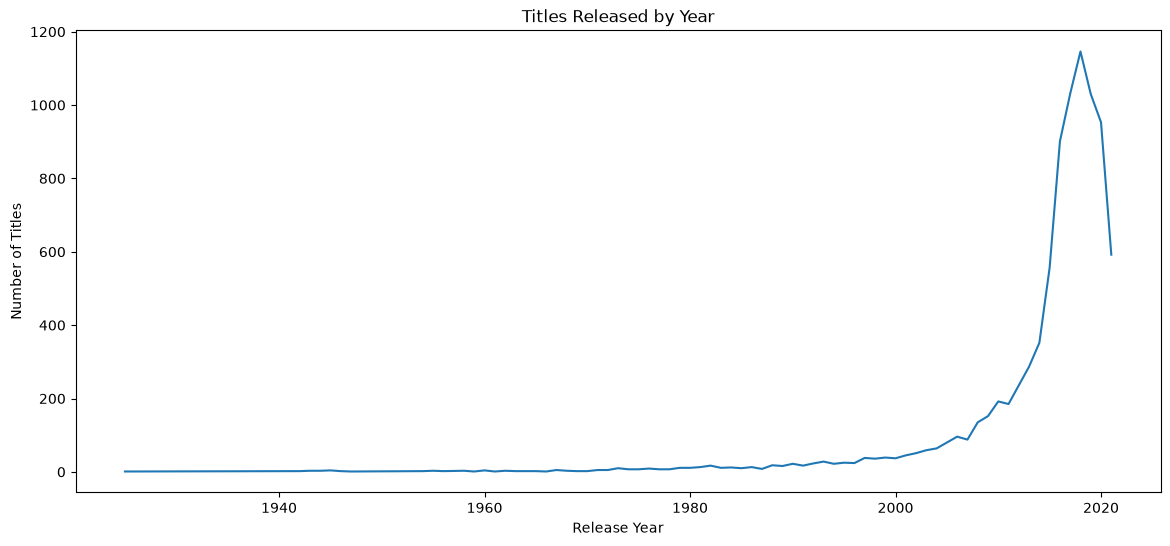

In [100]:
plt.figure(figsize=(14,6))

sns.lineplot(
    x=release_counts.index,
    y=release_counts.values
)

plt.title("Titles Released by Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.savefig("../images/content_added_by_year.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

# Business Insights

## Key Business Insights

### 1. Movies dominate Netflix's content library.
Movies account for a significantly larger portion of the catalog compared to TV Shows.

### 2. Netflix experienced rapid content growth after 2015.
The number of titles added increased substantially during this period.

### 3. The United States contributes the highest number of titles.
It remains Netflix's largest content-producing country.

### 4. Drama and International Movies are among the most common genres.
These categories dominate the platform.

### 5. Most movies have a duration between 80 and 120 minutes.
This represents the typical movie length on Netflix.

### 6. Most TV Shows contain only one season.
Limited series are more common than long-running shows.

### 7. TV-MA is the most frequent content rating.
Netflix contains a large amount of mature content.

### 8. Some directors and actors appear repeatedly.
A few creators contribute multiple titles to the platform.

### 9. Content additions vary by month.
Certain months show higher content additions than others.

### 10. Missing values mainly occurred in descriptive columns such as director, cast, and country.
Proper data cleaning ensured these records remained useful for analysis.

# Project Conclusion

This project analyzed the Netflix Movies and TV Shows dataset using Python, Pandas, Matplotlib, and Seaborn.

The analysis involved:

- Data Loading
- Data Inspection
- Data Cleaning
- Feature Engineering
- Exploratory Data Analysis
- Business Insights

The results show that Netflix's catalog is primarily composed of movies, with significant growth in content additions after 2015. The United States is the leading content-producing country, while Drama and International Movies are the most common genres. Most movies have durations between 80 and 120 minutes, and TV-MA is the most frequent content rating.

This project demonstrates a complete end-to-end data analysis workflow suitable for portfolio presentation and further business decision-making.

# Future Improvements

- Build an interactive dashboard using Power BI or Tableau.
- Perform sentiment analysis on movie descriptions.
- Develop a recommendation system using Machine Learning.
- Predict future content additions based on historical trends.
- Create a Streamlit web application for interactive exploration.

# Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

# Thank You

Thank you for exploring this Netflix Data Analysis project.

This project demonstrates a complete data analysis workflow, from raw data to actionable insights, and serves as a portfolio-ready example for aspiring Data Analysts and Data Scientists.